# 01 · Crawl the India destination graph (Wikivoyage)
States → regions → cities, via the public MediaWiki API (CC BY-SA). Code: `ml/scrape/wikivoyage.py`. Re-runs offline from the cache in `ml/data/raw/`.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
ROOT = r"C:\xampp\htdocs\travel_journel"
os.chdir(ROOT); sys.path.insert(0, ROOT)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 70)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": .3})
DATA = os.path.join(ROOT, "ml", "data")

In [2]:
nodes = pd.DataFrame(json.load(open(f"{DATA}/india_destinations.json", encoding="utf8")))
print(len(nodes), "nodes")
nodes.kind.value_counts()

1422 nodes


kind
city       1041
region      240
other       140
country       1
Name: count, dtype: int64

In [3]:
nodes[nodes.depth==1][["title","kind"]].T

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
title,Delhi,Bengaluru,Chennai,Hyderabad,Jaipur,Kolkata,Mumbai,Shimla,Varanasi,Himalayan North,Plains (India),Western India,Central India,Eastern India,North-Eastern India,Southern India
kind,city,city,city,city,city,city,city,city,city,region,region,region,region,region,region,region


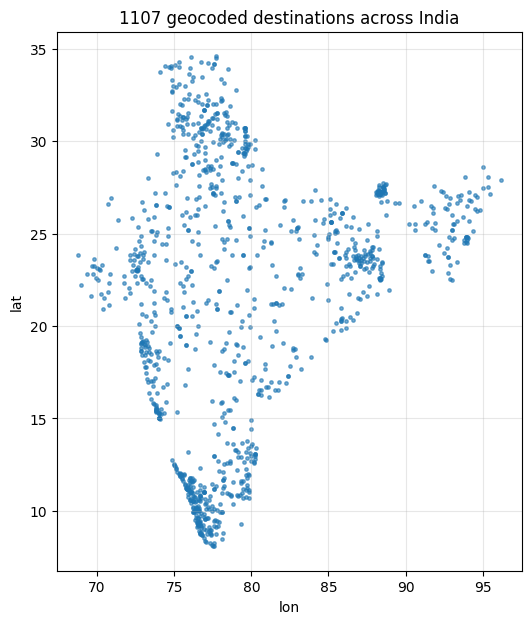

In [4]:
g = nodes.dropna(subset=["lat","lon"]); g = g[(g.lat.between(6,37))&(g.lon.between(68,98))]
plt.figure(figsize=(6,7)); plt.scatter(g.lon, g.lat, s=6, alpha=.6)
plt.title(f"{len(g)} geocoded destinations across India"); plt.xlabel("lon"); plt.ylabel("lat"); plt.show()

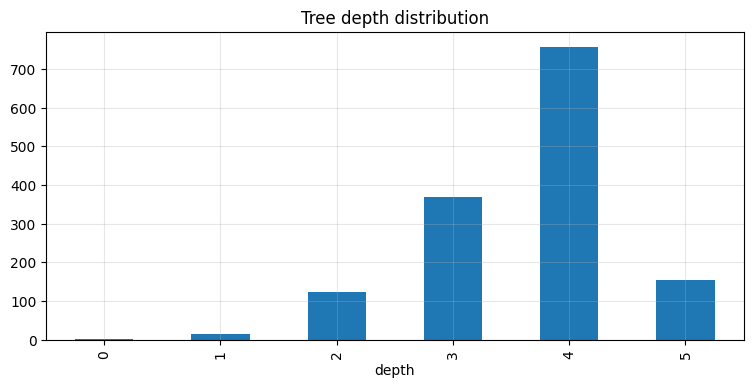

In [5]:
nodes.groupby("depth").size().plot.bar(title="Tree depth distribution"); plt.show()